# Refinement loss (material-point metric): with vs without adaptive refinement

The companion of `refinement_loss.ipynb`, scored with the **correspondence loss**
(`TrackedCorrespondenceLoss` in `mfem.refinement.surface_loss`) instead of the symmetric nearest-surface distance.
Each sim surface vertex is paired *once*, at the first recorded frame, with the closest point on a triangle of the
reference surface (barycentric weights on a fixed-topology template), and on every later frame is compared with
where that same material point of the reference went. The error is taken on displacement from the first frame, so
the coarse mesh's constant offset from the reference surface is not a floor. Unlike the nearest-surface distance
this is a true Lagrangian error: whole-body sliding and tangential slip under the poker are charged.

Only the vertices present at the first frame are scored (refinement appends new vertices past that prefix), so the
metric cannot move just because refinement adds vertices, and no tracked → sim direction is needed.

Two references, as before:

1. **the tracked dataset surface** (PlushOctopus_T1, rigid detrend), with pairs within 10 mm of the poker
   skipped on that frame, because the tracked mesh interpolates straight through the tool;
2. **the fine-mesh simulation** (`reference_runs/fine_default.npz`, 6431 vertices, same solver settings),
   which sees under the tool, isolating discretisation error.

Recordings are the benchmark-best sweep trials in `sweep_refine_geometric_work/` (geometric scoring, min edge 4 mm,
threshold 2) and the no-refinement runs in `sweep_refine_legacy_work/` (150 frames at 30 fps, 3 repeats per
setting). Curves show the mean over repeats; the wash is the min–max band across repeats. Run from the
repository root (or set `ROOT`).

In [1]:
import os, sys, glob, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("WARP_MFEM_ROOT", Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent))
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
try:  # the tracked-surface loader expects polyscope to be initialised
    import polyscope as ps; ps.init()
except Exception:
    pass
from mfem.refinement.tracked_surface import TrackedSurfaceOverlay
from mfem.refinement.surface_loss import (
    RecordingOverlay, TrackedSurfaceLoss, TrackedCorrespondenceLoss, score_recording, _load_recording,
)

TRACKED = "PlushOctopus_T1/mesh_trajectories_canonical.npy"
FINE_REFERENCE = "reference_runs/fine_default.npz"
EXCLUDE_TOOL_M = 0.01          # tracked-surface reference only
CACHE = ROOT / "notebooks" / "refinement_loss_correspondence_cache.npz"
KEY = "corr_mse"               # the correspondence column written by score_recording(corr=...)

# label -> recordings (repeats). Edit to compare other sweep trials.
RUNS = {
    "with refinement": sorted(glob.glob(
        "sweep_refine_geometric_work/rec_refine_geometric_threshold=2.0_refine_min_edge_length=0.004*.npz")),
    "without refinement": sorted(glob.glob("sweep_refine_legacy_work/rec_norefine*.npz")),
}
# the geometric-best glob also matches its tri-contact-weight variants; keep only the plain trial + repeats
RUNS["with refinement"] = [p for p in RUNS["with refinement"] if "tri_contact" not in p]
for k, v in RUNS.items():
    print(f"{k:34s} {len(v)} recording(s)")

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 26.1.6-1pop0~1787580452~24.04~a5619ea


with refinement                    3 recording(s)
without refinement                 3 recording(s)


In [2]:
def build_losses():
    """(surface loss, correspondence loss) per reference. The surface loss is still
    scored so the old symmetric metric rides along in the same curve for comparison."""
    start = _load_recording(next(iter(RUNS.values()))[0])["start_frame"]
    tracked = TrackedSurfaceOverlay(TRACKED, alpha=0.0, start_frame=start, detrend="rigid")
    fine = RecordingOverlay(FINE_REFERENCE)
    return {
        "vs tracking": (TrackedSurfaceLoss(tracked, symmetric=True, exclude_tool_margin=EXCLUDE_TOOL_M),
                        TrackedCorrespondenceLoss(tracked, exclude_tool_margin=EXCLUDE_TOOL_M)),
        "vs fine simulation": (TrackedSurfaceLoss(fine, symmetric=True),
                               TrackedCorrespondenceLoss(fine)),
    }

def load_cache():
    if CACHE.exists():
        with np.load(CACHE, allow_pickle=True) as d:
            return dict(d["curves"].item())
    return {}

def save_cache(curves):
    CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(CACHE, curves=np.array(curves, dtype=object))

# The fine simulation is also scored against the tracking (left panel only): it
# bounds what a much finer mesh buys under the same material / contact model.
FINE_LABEL = "fine mesh (no refinement)"
TO_SCORE = [(ref, p) for ref in ("vs tracking", "vs fine simulation") for paths in RUNS.values() for p in paths]
TO_SCORE.append(("vs tracking", FINE_REFERENCE))

curves = load_cache()           # (reference, recording path) -> per-frame dict
losses = None
for ref, p in TO_SCORE:
    if (ref, p) in curves:
        continue
    losses = losses or build_losses()
    print(f"scoring {p} {ref} ...", flush=True)
    surf_loss, corr_loss = losses[ref]
    # A fresh correspondence per recording: bind() fixes the pairing to that recording's first frame.
    corr_loss = TrackedCorrespondenceLoss(corr_loss.overlay, exclude_tool_margin=corr_loss.exclude_tool_margin)
    curves[(ref, p)] = score_recording(p, surf_loss, corr=corr_loss)
    save_cache(curves)
print(f"{len(curves)} curves ready")

tracked surface: whole-body detrend = rigid (reference frame 19)


tracked surface overlay: 155 frames, 15002 verts, 30000 tris, alpha 0  (PlushOctopus_T1/mesh_trajectories_canonical.npy)
scoring sweep_refine_geometric_work/rec_refine_geometric_threshold=2.0_refine_min_edge_length=0.004.npz vs tracking ...


[correspondence] bound 443 surface vertices to tracked frame 20 (bind residual RMS 2.06 mm, max 6.29 mm, unbound 0)


scoring sweep_refine_geometric_work/rec_refine_geometric_threshold=2.0_refine_min_edge_length=0.004_r1.npz vs tracking ...


[correspondence] bound 443 surface vertices to tracked frame 20 (bind residual RMS 2.06 mm, max 6.29 mm, unbound 0)


...

scoring sweep_refine_legacy_work/rec_norefine_r2.npz vs fine simulation ...


[correspondence] bound 442 surface vertices to tracked frame 0 (bind residual RMS 0.81 mm, max 3.70 mm, unbound 0)


scoring reference_runs/fine_default.npz vs tracking ...


[correspondence] bound 5618 surface vertices to tracked frame 20 (bind residual RMS 2.17 mm, max 8.21 mm, unbound 0)


13 curves ready


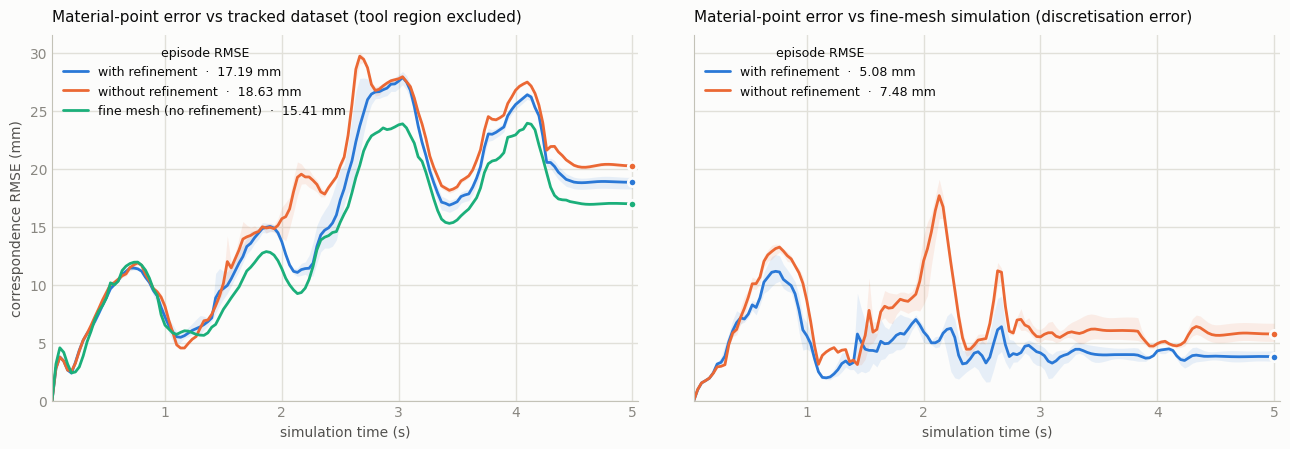

In [3]:
# --- chart style (design-system tokens) ---------------------------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = {                       # fixed categorical order: blue, orange
    "with refinement": "#2a78d6",
    "without refinement": "#eb6834",
    "fine mesh (no refinement)": "#1baf7a",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def stack(ref, label, key=KEY):
    rows = [np.asarray(curves[(ref, p)][key], dtype=float) for p in RUNS[label]]
    n = min(len(r) for r in rows)
    t = np.asarray(curves[(ref, RUNS[label][0])]["time"], dtype=float)[:n]
    a = np.stack([r[:n] for r in rows])
    return t, a

def episode_rmse_mm(a):
    """RMS over frames and repeats, i.e. sqrt of the sweep's mean-MSE objective."""
    return math.sqrt(a.mean()) * 1e3

def plot_reference(ax, ref, title, key=KEY):
    # The lines converge at the right edge, so identity + the episode figure live in
    # the legend (text in ink, colour only on the swatch); end dots mark the last frame.
    for label in RUNS:
        t, a = stack(ref, label, key)
        rmse = np.sqrt(a) * 1e3                       # per repeat, mm
        mean = np.sqrt(a.mean(0)) * 1e3
        c = SERIES[label]
        ax.fill_between(t, rmse.min(0), rmse.max(0), color=c, alpha=0.10, linewidth=0)
        ax.plot(t, mean, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{label}  ·  {episode_rmse_mm(a):.2f} mm")
        ax.plot([t[-1]], [mean[-1]], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    if (ref, FINE_REFERENCE) in curves:          # single run, no repeat band
        cf = curves[(ref, FINE_REFERENCE)]
        tf = np.asarray(cf["time"], dtype=float); af = np.asarray(cf[key], dtype=float)[None, :]
        c = SERIES[FINE_LABEL]
        ax.plot(tf, np.sqrt(af[0]) * 1e3, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{FINE_LABEL}  ·  {episode_rmse_mm(af):.2f} mm")
        ax.plot([tf[-1]], [np.sqrt(af[0, -1]) * 1e3], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.set_title(title, loc="left", fontsize=11, color=INK, pad=10)
    ax.legend(loc="upper left", frameon=False, fontsize=9, title="episode RMSE", title_fontsize=9)
    ax.set_xlabel("simulation time (s)")
    ax.set_xlim(t[0], t[-1] + 0.05)
    ax.set_ylim(0, None)
    ax.tick_params(length=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
plot_reference(axes[0], "vs tracking", "Material-point error vs tracked dataset (tool region excluded)")
plot_reference(axes[1], "vs fine simulation", "Material-point error vs fine-mesh simulation (discretisation error)")
axes[0].set_ylabel("correspondence RMSE (mm)")
fig.tight_layout(w_pad=4)
fig.savefig(ROOT / "notebooks" / "refinement_loss_correspondence.png", dpi=150, bbox_inches="tight")
plt.show()

The two panels share one y-axis. Compared with the nearest-surface metric in `refinement_loss.ipynb`, every curve
sits higher because tangential motion now counts: against the tracking the floor set by modelling error (material,
friction, the body's rigid slide) is larger, and against the fine simulation the discretisation error includes where
the coarse surface ends up along the surface, not only how far off it it is.

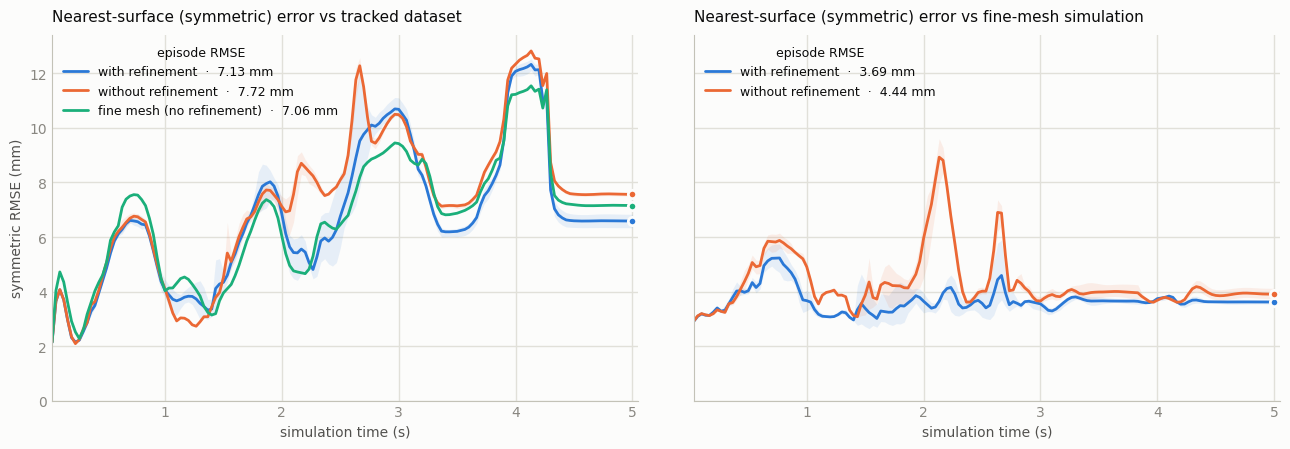

In [4]:
# Same panels under the old symmetric nearest-surface metric, from the same scoring pass, for a direct comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
plot_reference(axes[0], "vs tracking", "Nearest-surface (symmetric) error vs tracked dataset", key="mse_symmetric")
plot_reference(axes[1], "vs fine simulation", "Nearest-surface (symmetric) error vs fine-mesh simulation", key="mse_symmetric")
axes[0].set_ylabel("symmetric RMSE (mm)")
fig.tight_layout(w_pad=4); plt.show()

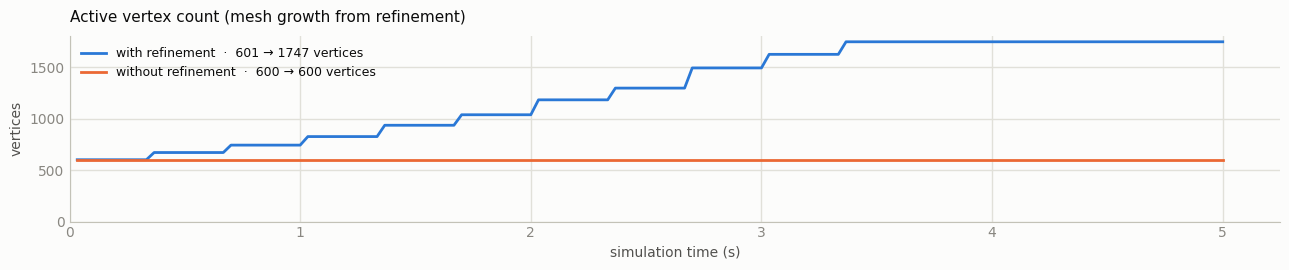

In [5]:
# Mesh growth for context: when and how much each run refines
fig, ax = plt.subplots(figsize=(13, 2.8))
for label in RUNS:
    p = RUNS[label][0]
    rec = _load_recording(p)
    n = [len(rec["positions_at"](i)) for i in range(rec["frame_count"])]
    ax.plot(rec["times"][:len(n)], n, color=SERIES[label], linewidth=2,
            label=f"{label}  ·  {n[0]} → {n[-1]} vertices")
ax.set_title("Active vertex count (mesh growth from refinement)", loc="left", fontsize=11, pad=10)
ax.set_xlabel("simulation time (s)"); ax.set_ylabel("vertices")
ax.set_xlim(0, None); ax.set_ylim(0, None); ax.tick_params(length=0)
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

In [6]:
# Summary table: episode RMSE per run, reference and metric, and the MSE change vs no refinement
rows = []
for metric, key in (("correspondence", KEY), ("symmetric surface", "mse_symmetric")):
    for ref in ("vs tracking", "vs fine simulation"):
        base = np.sqrt(stack(ref, "without refinement", key)[1].mean())
        if (ref, FINE_REFERENCE) in curves:
            af = np.asarray(curves[(ref, FINE_REFERENCE)][key], dtype=float)
            rows.append({"metric": metric, "reference": ref, "run": FINE_LABEL,
                         "episode RMSE mm": episode_rmse_mm(af), "repeat spread mm": "single run",
                         "MSE change vs no refinement": f"{(af.mean() / base**2 - 1) * 100:+.0f}%"})
        for label in RUNS:
            t, a = stack(ref, label, key)
            per_repeat = np.sqrt(a.mean(1)) * 1e3
            rows.append({
                "metric": metric, "reference": ref, "run": label,
                "episode RMSE mm": episode_rmse_mm(a),
                "repeat spread mm": f"{per_repeat.min():.2f} – {per_repeat.max():.2f}",
                "MSE change vs no refinement": f"{(a.mean() / base**2 - 1) * 100:+.0f}%",
            })
pd.DataFrame(rows).round(2)

,metric,reference,run,episode RMSE mm,repeat spread mm,MSE change vs no refinement
0,correspondence,vs tracking,fine mesh (no refinement),15.41,single run,-32%
1,correspondence,vs tracking,with refinement,17.19,16.69 – 17.75,-15%
2,correspondence,vs tracking,without refinement,18.63,18.54 – 18.80,+0%
3,correspondence,vs fine simulation,with refinement,5.08,4.52 – 5.47,-54%
4,correspondence,vs fine simulation,without refinement,7.48,7.31 – 7.65,+0%
5,symmetric surface,vs tracking,fine mesh (no refinement),7.06,single run,-16%
6,symmetric surface,vs tracking,with refinement,7.13,6.94 – 7.32,-15%
7,symmetric surface,vs tracking,without refinement,7.72,7.68 – 7.79,+0%
8,symmetric surface,vs fine simulation,with refinement,3.69,3.53 – 3.82,-31%
9,symmetric surface,vs fine simulation,without refinement,4.44,4.38 – 4.54,-0%
